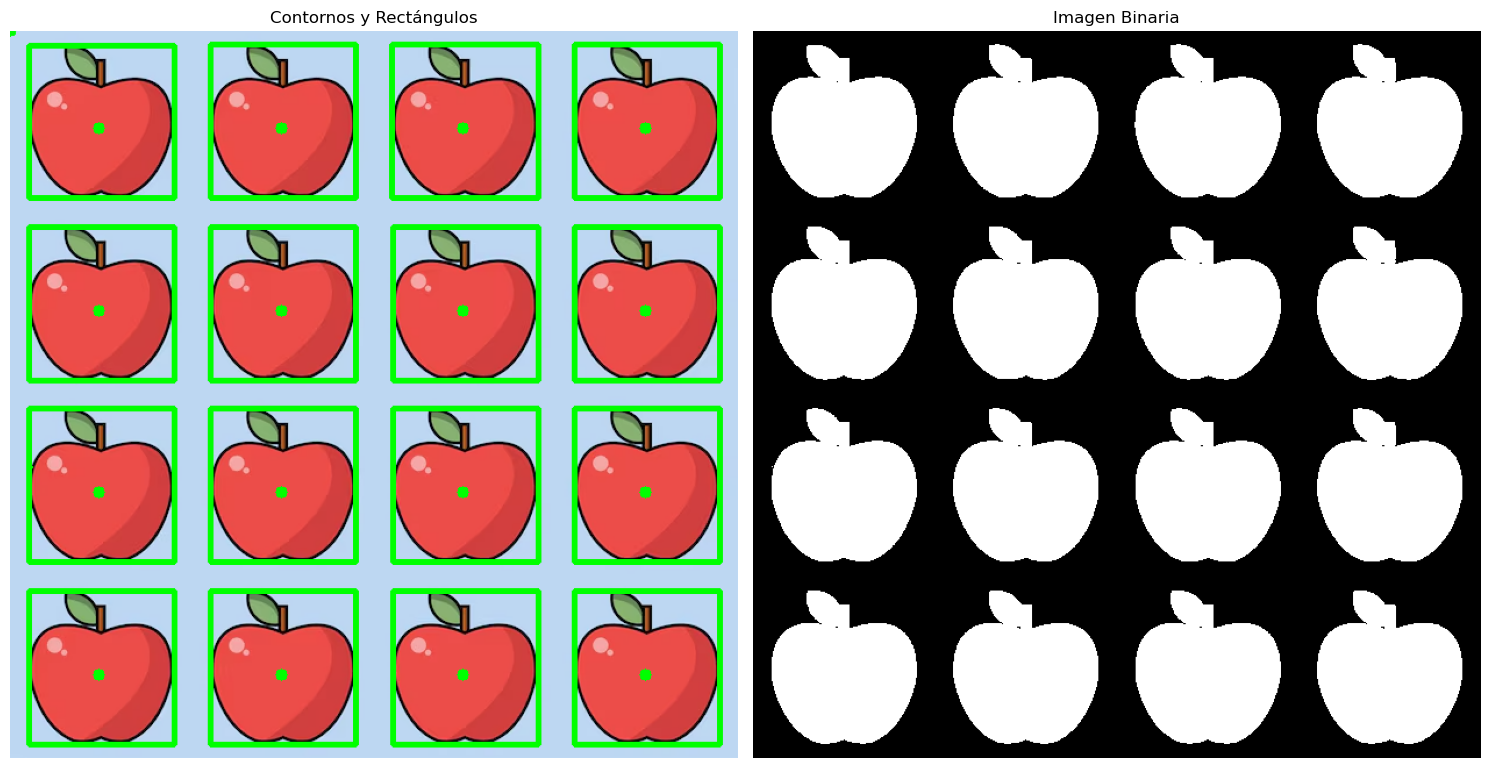

Contorno 1: Perímetro = 12.33 cm, Área = 306.15 cm^2
Contorno 2: Perímetro = 12.36 cm, Área = 305.91 cm^2
Contorno 3: Perímetro = 12.33 cm, Área = 306.04 cm^2
Contorno 4: Perímetro = 12.34 cm, Área = 305.79 cm^2
Contorno 5: Perímetro = 0.00 cm, Área = 0.00 cm^2
Contorno 6: Perímetro = 12.47 cm, Área = 306.08 cm^2
Contorno 7: Perímetro = 12.43 cm, Área = 306.10 cm^2
Contorno 8: Perímetro = 12.44 cm, Área = 306.18 cm^2
Contorno 9: Perímetro = 12.45 cm, Área = 306.03 cm^2
Contorno 10: Perímetro = 12.40 cm, Área = 305.78 cm^2
Contorno 11: Perímetro = 12.34 cm, Área = 305.90 cm^2
Contorno 12: Perímetro = 12.34 cm, Área = 305.73 cm^2
Contorno 13: Perímetro = 12.33 cm, Área = 305.78 cm^2
Contorno 14: Perímetro = 12.38 cm, Área = 305.75 cm^2
Contorno 15: Perímetro = 12.47 cm, Área = 305.92 cm^2
Contorno 16: Perímetro = 12.44 cm, Área = 306.19 cm^2
Contorno 17: Perímetro = 12.44 cm, Área = 306.10 cm^2


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('manzanas.avif')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)[1]

contorno, jerarquía = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []
for i in range(len(contorno)):
    cont = contorno[i]
    M = cv2.moments(cont)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0

    area = cv2.contourArea(cont)
    perimetro = cv2.arcLength(cont, True)

    areas.append(area)
    perimetros.append(perimetro)

    cv2.circle(image, (cx, cy), 5, (0, 255, 0), -1)

    x, y, w, h = cv2.boundingRect(cont)
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.figure(figsize=(15, 15))
plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Contornos y Rectángulos')
plt.axis('off')

plt.subplot(122)
plt.imshow(bin, cmap='gray')
plt.title('Imagen Binaria')
plt.axis('off')
plt.tight_layout()
plt.show()

for i, (perimetro, area) in enumerate(zip(perimetros, areas)):
    print(f"Contorno {i + 1}: Perímetro = {perimetro/37.795276:.2f} cm, Área = {area/37.795276:.2f} cm^2")

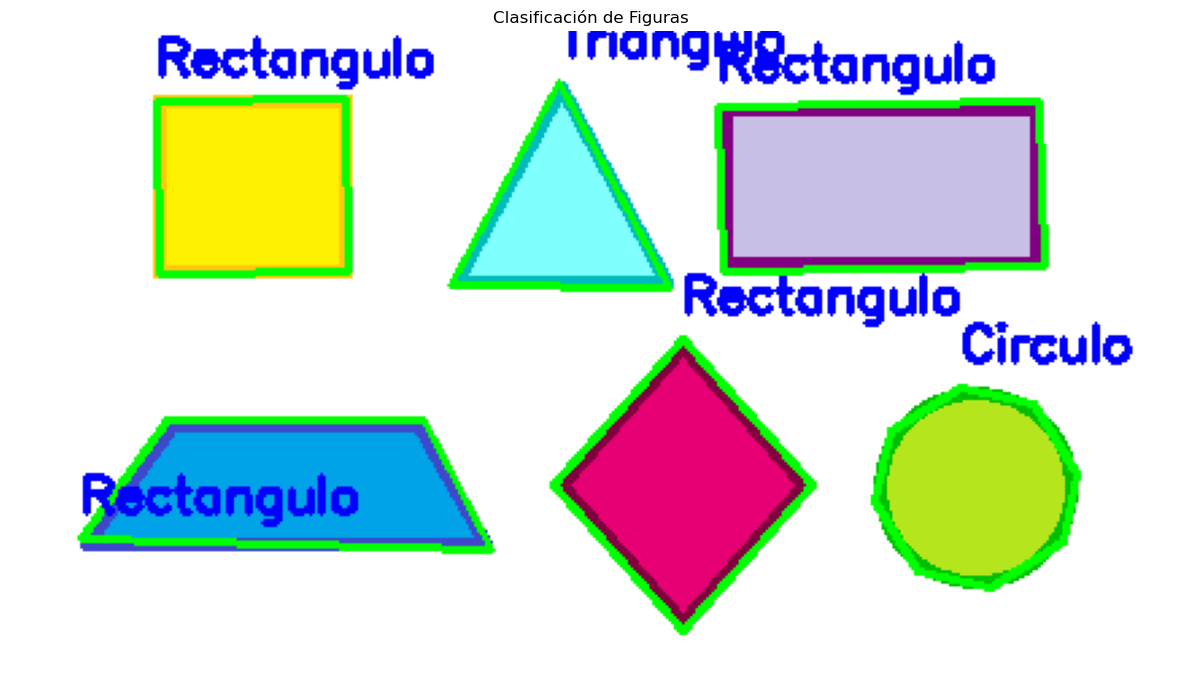

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('formas.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
bin = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY_INV)[1]
contornos = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

for cnt in contornos:
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    momentos = cv2.moments(cnt)
    huMomentos = cv2.HuMoments(momentos)
    forma = "Indefinido"
    vertices = len(approx)
    if vertices == 3:
        forma = "Triangulo"
    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w)/h
        forma = "Cuadrado" if 0.95 <= aspect_ratio <= 1.05 else "Rectangulo"
    elif vertices > 5:
        forma = "Circulo"
    cv2.drawContours(img, [approx], -1, (0, 255, 0), 2)
    x, y = approx.ravel()[0], approx.ravel()[1]
    cv2.putText(img, forma, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Clasificación de Figuras")
plt.show()
